In [80]:
%load_ext autoreload
%autoreload 2 

data_folder = "../data/"

import numpy as np
import pandas as pd

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "axes.linewidth": 0.9,
    "xtick.major.width": 0.9,
    "ytick.major.width": 0.9,
    "xtick.minor.width": 0.7,
    "ytick.minor.width": 0.7,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import LogLocator
import plotting_utils as pu
from matplotlib.patches import Patch
from matplotlib import color_sequences
from matplotlib.colors import TwoSlopeNorm

#import networkx as nx # graph visualization of MSM microstates and macrostates model

from deeptime.markov import TransitionCountEstimator
from deeptime.markov.msm import MaximumLikelihoodMSM


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Spectral analysis and structural interpretation

Reload data (after clustering)

In [94]:
trajectories_labels = ["tica_distances", "pca_distances", "tica_dihedrals", "pca_dihedrals"]



total_time_micros = 300
time_step_micros =  total_time_micros / 1526041 #/ distances.shape[0]
time_step_nanos = time_step_micros * 10**3
print("Time step (microseconds)", time_step_micros) # 2x10^-4 microseconds
print("Time step (nanoseconds)", time_step_micros * 10**3) # 0.2 nanoseconds
print("Time step (picoseconds)", time_step_micros * 10**6) # 200 picoseconds
one_microsecond_in_frames = int(1 / time_step_micros)
print("One microsecond in frames", one_microsecond_in_frames) # 5000 frames

Time step (microseconds) 0.00019658711659778472
Time step (nanoseconds) 0.19658711659778472
Time step (picoseconds) 196.58711659778473
One microsecond in frames 5086


Fit MSM with previously chosen and validated lagtime

In [82]:
msm_lag = 100 # 20 ns
n_clusters = 100
tce = TransitionCountEstimator(lagtime=msm_lag, count_mode="sliding-effective")

msm_dict = {}
micro_trajectory_dict = {} # traj -> micro traj
clean_micro_trajectory_dict = {} # traj -> micro traj
cluster_centers_dict = {} # cluster centers 


for i, name in enumerate(trajectories_labels):
    data = np.load(f"../intermediate_outputs/kmeans/{n_clusters}clusters_{name}.npz")
    dtraj = data["traj"].copy()
    centers = data["centers"].copy()
    C = tce.fit(dtraj).fetch_model()
    submodel = C.submodel_largest(connectivity_threshold=1., directed=True)

    cluster_centers_dict[name] = submodel.transform_discrete_trajectories_to_submodel(np.arange(n_clusters))
    micro_trajectory_dict[name] = submodel.transform_discrete_trajectories_to_submodel(data["traj"])
    np.save(f"../intermediate_outputs/microstate_trajs/{n_clusters}clusters_{msm_lag}lag_{name}_submodel.npy", micro_trajectory_dict[name])

    clean_micro_trajectory_dict[name] = pu.clean_assignments(micro_trajectory_dict[name], max_dist= 10000)
    if np.any(clean_micro_trajectory_dict[name] == -1):
        print(f"Warning: {name} has unassigned microstates after cleaning.")
    msm = MaximumLikelihoodMSM(reversible = True).fit(submodel).fetch_model()
    msm_dict[name] = msm

Plot eigenvalues and timescales

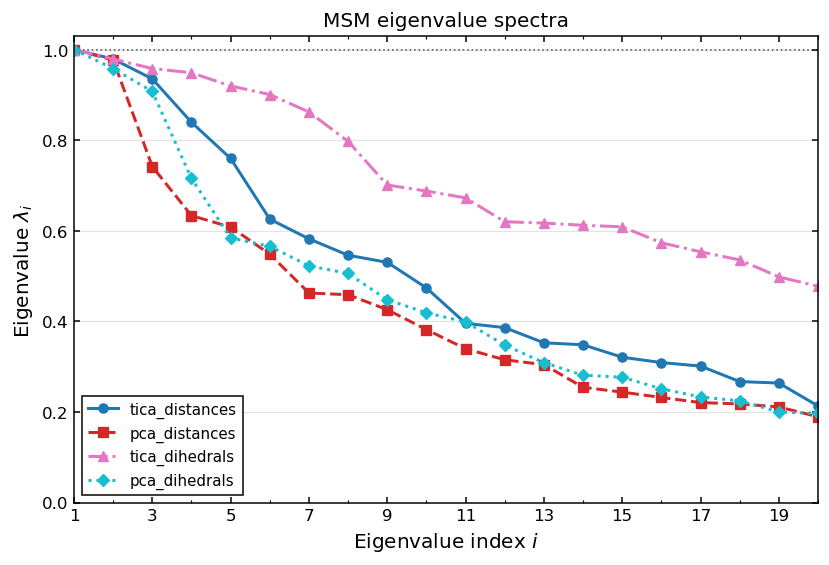

In [83]:


# ---------------------------------------------------------------------------
# Report-quality eigenvalue spectrum plot: all MSMs in one panel

os.makedirs("../output_figures", exist_ok=True)


n_eigs = 20
eig_indices = np.arange(1, n_eigs + 1)

fig, ax = plt.subplots(figsize=(6.8, 4.6), constrained_layout=True)

# Good default color cycle
colors = plt.cm.tab10(np.linspace(0, 1, len(trajectories_labels)))
markers = ["o", "s", "^", "D", "v", "P", "X", "*"]
linestyles = ["-", "--", "-.", ":"]

for i, name in enumerate(trajectories_labels):
    msm = msm_dict[name]
    eigvals = np.asarray(msm.eigenvalues(k=n_eigs))

    ax.plot(
        eig_indices,
        eigvals,
        marker=markers[i % len(markers)],
        linestyle=linestyles[i % len(linestyles)],
        linewidth=1.8,
        markersize=5.5,
        markeredgewidth=0.8,
        color=colors[i],
        label=name
    )

# Reference line at lambda = 1
ax.axhline(
    1.0,
    color="black",
    linestyle=":",
    linewidth=1.0,
    alpha=0.7,
    zorder=0
)

ax.set_xlabel(r"Eigenvalue index $i$")
ax.set_ylabel(r"Eigenvalue $\lambda_i$")
ax.set_title("MSM eigenvalue spectra")

ax.set_xlim(1, n_eigs)
ax.set_ylim(0, 1.03)

ax.set_xticks(np.arange(1, n_eigs + 1, 2))
ax.set_xticks(np.arange(1, n_eigs + 1, 1), minor=True)

ax.grid(
    which="major",
    axis="y",
    linestyle="-",
    linewidth=0.7,
    alpha=0.35
)

ax.grid(
    which="minor",
    axis="y",
    linestyle=":",
    linewidth=0.5,
    alpha=0.25
)

ax.legend(
    title=None,
    frameon=True,
    fancybox=False,
    edgecolor="black",
    framealpha=0.9,
    loc="best"
)

fig.savefig(
    "../output_figures/msm_eigenvalue_spectra_report.png",
    dpi=600,
    bbox_inches="tight"
)

fig.savefig(
    "../output_figures/msm_eigenvalue_spectra_report.pdf",
    bbox_inches="tight"
)

plt.show()

Comment: there is no evident separation of timescales.
this indicates a rather "flat" free energy landscape, with low barriers between basins, even between the native and denatured basin. This is consistent with the fact that the system under study is an protein that was engineered to fold extremely fast, close to physical limit. 

Markov chain lag: 19.66 ns (100 frames)


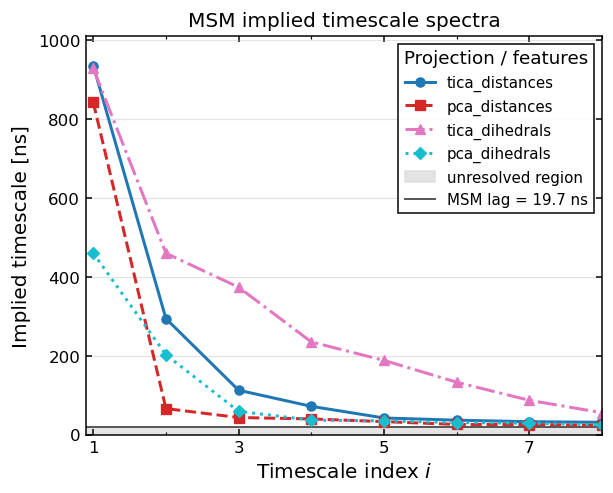

In [84]:
# ---------------------------------------------------------------------------
# Report-quality timescale spectrum plot: all MSMs in one panel

n_timescales = 8
msm_lag_ns = msm_lag * time_step_nanos
print(f"Markov chain lag: {msm_lag_ns:.2f} ns ({msm_lag} frames)")

# ---------------------------------------------------------------------------
# Figure

fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)

colors = plt.cm.tab10(np.linspace(0, 1, len(trajectories_labels)))
markers = ["o", "s", "^", "D", "v", "P", "X", "*"]
linestyles = ["-", "--", "-.", ":"]

for i, name in enumerate(trajectories_labels):
    msm = msm_dict[name]

    timescales_ns = np.asarray(msm.timescales(k=n_timescales)) * time_step_nanos
    indices = np.arange(1, len(timescales_ns) + 1)


    ax.plot(
        indices,
        timescales_ns,
        marker=markers[i % len(markers)],
        linestyle=linestyles[i % len(linestyles)],
        linewidth=1.8,
        markersize=5.5,
        markeredgewidth=0.8,
        color=colors[i],
        label=rf"{name}"
    )

# ---------------------------------------------------------------------------
# MSM lag and threshold annotations

ax.axhspan(
    0,
    msm_lag_ns,
    color="0.85",
    alpha=0.7,
    zorder=0,
    label="unresolved region"
)

ax.axhline(
    msm_lag_ns,
    color="0.35",
    linestyle="-",
    linewidth=1.2,
    zorder=1,
    label=rf"MSM lag = {msm_lag_ns:.1f} ns"
)


# ---------------------------------------------------------------------------
# Axes formatting

ax.set_xlabel(r"Timescale index $i$")
ax.set_ylabel("Implied timescale [ns]")
ax.set_title("MSM implied timescale spectra")

ax.set_xlim(0.9, n_timescales)
ax.set_xticks(np.arange(1, n_timescales + 1, 2))
ax.set_xticks(np.arange(1, n_timescales + 1, 1), minor=True)

# Let the upper y-limit adapt to the data, threshold included
all_timescales = []

for name in trajectories_labels:
    msm = msm_dict[name]
    all_timescales.append(np.asarray(msm.timescales(k=n_timescales)) * time_step_nanos)

all_timescales = np.concatenate(all_timescales)
finite_timescales = all_timescales[np.isfinite(all_timescales)]

ymax = max(
    np.nanmax(finite_timescales),
    #threshold_ns,
    msm_lag_ns
)

ax.set_ylim(0, 1.08 * ymax)

ax.grid(
    which="major",
    axis="y",
    linestyle="-",
    linewidth=0.7,
    alpha=0.35
)

ax.grid(
    which="minor",
    axis="y",
    linestyle=":",
    linewidth=0.5,
    alpha=0.25
)

ax.legend(
    title="Projection / features",
    frameon=True,
    fancybox=False,
    edgecolor="black",
    framealpha=0.9,
    loc="best"
)
# ---------------------------------------------------------------------------
# Save figure
fig.savefig(
    "../output_figures/msm_timescale_spectra_report.png",
    dpi=600,
    bbox_inches="tight"
)
fig.savefig(
    "../output_figures/msm_timescale_spectra_report.pdf",
    bbox_inches="tight"
)
plt.show()

## Leading eigenvector: slowest exchange mode

In [85]:
# Reloade reduced trajectories

tica_lag = 100 # lag time for TICA in frames, 1000 frames = 200 nanoseconds
tica_dim_distances = 5
tica_dim_dihedrals = 7
pca_dim_distances = 5
pca_dim_dihedrals = 7


tica_dihedrals = np.load(f"../intermediate_outputs/dimred/tica_lag_{tica_lag}_dim_{tica_dim_dihedrals}_dihedrals.npy")
pca_dihedrals = np.load(f"../intermediate_outputs/dimred/pca_dim_{pca_dim_dihedrals}_dihedrals.npy")
tica_distances = np.load(f"../intermediate_outputs/dimred/tica_lag_{tica_lag}_dim_{tica_dim_distances}_distances.npy")
pca_distances = np.load(f"../intermediate_outputs/dimred/pca_dim_{pca_dim_distances}_distances.npy")


trajectories = [tica_distances, pca_distances, tica_dihedrals, pca_dihedrals]

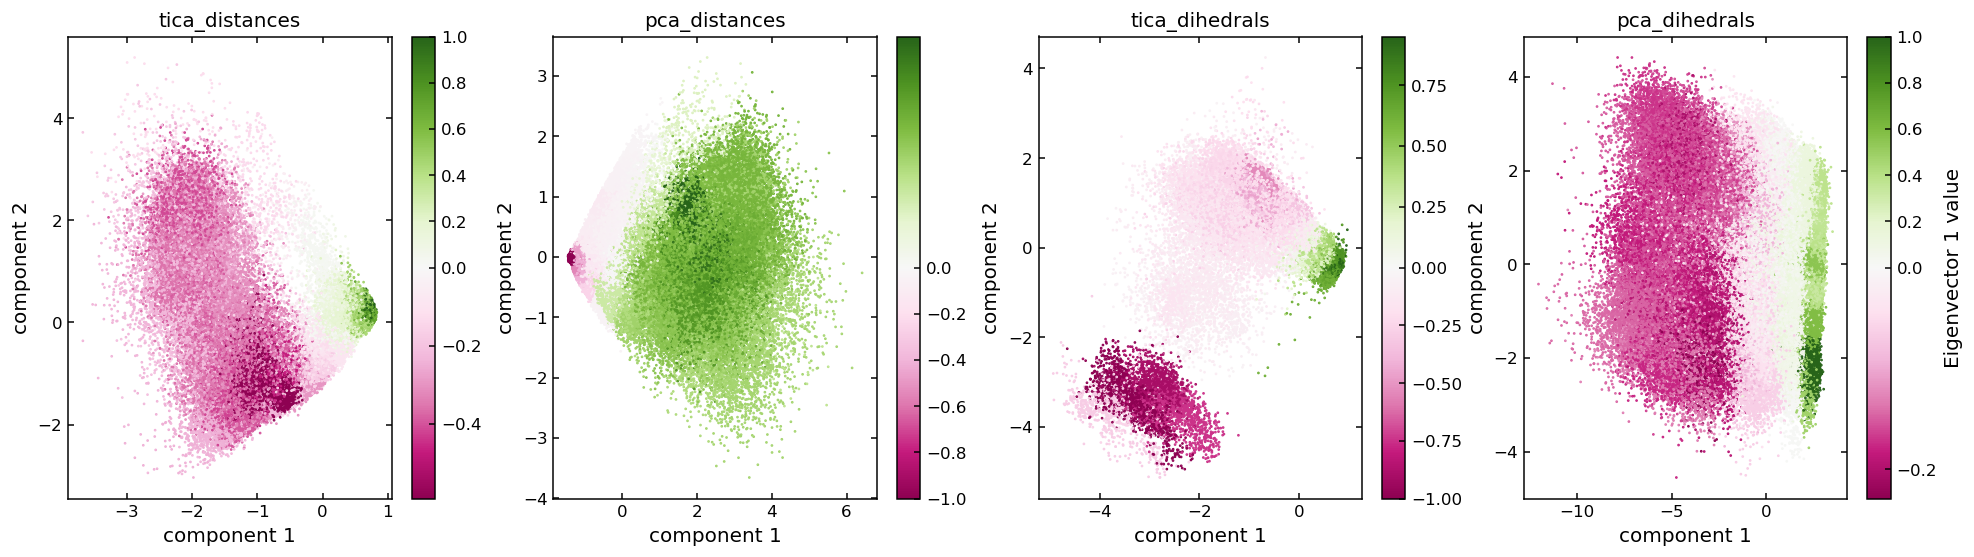

In [86]:
# Plotting the first three eigenvectors of the MSMs
eigvecs_to_plot = 1

fig, axs = plt.subplots(
    nrows=eigvecs_to_plot,
    ncols=4,
    figsize=(20, 5 * eigvecs_to_plot),
    squeeze=False,  # always return a 2D array
)


for i, name in enumerate(trajectories_labels):
    msm = msm_dict[name]
    #R = msm.eigenvectors_right(k=eigvecs_to_plot + 1)[:, 1:] # skip the first one which is np.ones

    L = msm.eigenvectors_left(k=eigvecs_to_plot+1)[1:, :].T # includes the first one which is np.ones, but we will plot it as well for reference
    # renormalize each eigenvector to range approximately from -1 to 1 for better visualization
    #R_normalized = R / np.abs(R).max(axis=0)
    L_normalized = L / np.abs(L).max(axis=0)


    traj = micro_trajectory_dict[name]
    # transform  to eigvec values
    z_values = np.full((len(traj), eigvecs_to_plot), np.nan)
    mask = traj != -1
    #z_values[mask] = R_normalized[traj[mask], :eigvecs_to_plot]
    z_values[mask] = L_normalized[traj[mask], :eigvecs_to_plot]

    xy = trajectories[i]

    for row in range(eigvecs_to_plot):
        ax = axs[row, i]
        #ax = axs[i]
        norm = TwoSlopeNorm(vcenter=0.0)
        
        ax.scatter(xy[:, 0][::10], xy[:, 1][::10], c = z_values[::10, row], norm = norm, cmap = "PiYG", s=0.4, alpha=1)
        if i == len(trajectories_labels) - 1:
            plt.colorbar(ax.collections[0], ax=ax, label=f"Eigenvector {row+1} value")
        else:
            plt.colorbar(ax.collections[0], ax=ax)
        ax.set_xlabel("component 1")
        ax.set_ylabel("component 2")
        ax.set_title(f"{name}")    

---
# PCCA into two components: consistency between models, populations, structural caracterization

In [87]:
pcca_dict = {}
for name in trajectories_labels:
    msm = msm_dict[name]
    pcca = msm.pcca(2)
    pcca_dict[name] = pcca

In [88]:
pcca_probabilities_timeseries_dict = {}


for i, name in enumerate(trajectories_labels):
    pcca = pcca_dict[name]
    micro_proba = pcca.memberships[:, 0]
    dict = {i: p for i, p in enumerate(micro_proba)}

    # convert microstate trajectory to macrostate probabilities timeseries
    input_traj = clean_micro_trajectory_dict[name] # microstate trajectory
    output_traj = np.array([dict[i] for i in input_traj]) # macrostate probabilities timeseries
    pcca_probabilities_timeseries_dict[name] = output_traj

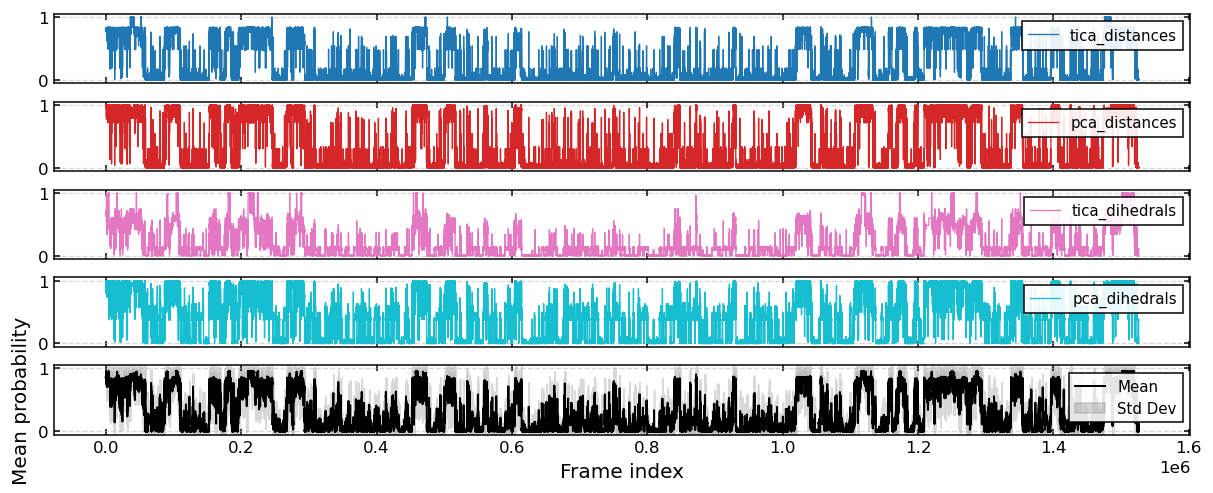

In [ ]:
start_frame = one_microsecond_in_frames * 9
end_frame = one_microsecond_in_frames * 14


fig, axs = plt.subplots(
    nrows=5,
    ncols=1,
    figsize=(10, 4),
    constrained_layout=True,
    sharex=True
)
for i, name in enumerate(trajectories_labels):
    ax = axs[i]
    ax.plot(pcca_probabilities_timeseries_dict[name], color=colors[i], linewidth=0.8, label = f"{name}")
    ax.set_ylabel(f"")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.legend(loc="upper right", frameon=True, fancybox=False, edgecolor="black", framealpha=0.9)


# Add mean and standard deviation (consensus plot)
mean_probabilities = np.mean(list(pcca_probabilities_timeseries_dict.values()), axis=0)
std_probabilities = np.std(list(pcca_probabilities_timeseries_dict.values()), axis=0)
ax = axs[-1]
ax.plot(mean_probabilities, color="black", linewidth=1.2, label="Mean")
ax.fill_between(
    np.arange(len(mean_probabilities)),
    mean_probabilities - std_probabilities,
    mean_probabilities + std_probabilities,
    color="gray",
    alpha=0.3,
    label="Std Dev"
)
ax.set_ylabel("Mean probability")
ax.set_xlabel("Frame index")
ax.set_ylim(-0.05, 1.05)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.legend(loc="upper right", frameon=True, fancybox=False, edgecolor="black", framealpha=0.9)

Time series correlation

both 
- $p_A$ vs $p_B$
- $p_A$ vs $1 - p_B$

to account for label switching


Also correlation with the RMSD and Q, to understand how much we can identify pcca state with folding.

In [90]:
correlation_matrix = np.zeros((len(trajectories_labels), len(trajectories_labels)))

for i, name in enumerate(trajectories_labels):
    for j, other_name in enumerate(trajectories_labels):
        if i != j:
            # Compute correlation between the two macrostate probability timeseries
            corr = np.corrcoef(pcca_probabilities_timeseries_dict[name], pcca_probabilities_timeseries_dict[other_name])[0, 1]
            correlation_matrix[i, j] = corr

<Axes: >

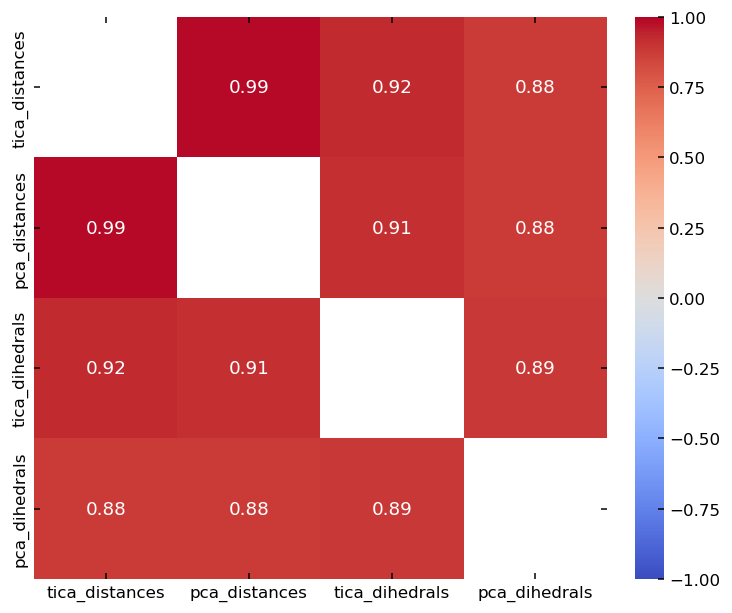

In [91]:
# print results
for i, name in enumerate(trajectories_labels):
    for j, other_name in enumerate(trajectories_labels):
        if i != j:
            continue
            #print(f"Correlation between {name} and {other_name}: {correlation_matrix_max[i, j]:.4f}")

# heatmap of the correlation matrix
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
# nan on diagonal
np.fill_diagonal(correlation_matrix, np.nan)
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    xticklabels=trajectories_labels,
    yticklabels=trajectories_labels,
    ax=ax
)

Comment: very good agreement between the partitions

Are the two partitions mostly self-transitioning?

In [93]:
for i, name in enumerate(trajectories_labels):
    pcca = pcca_dict[name]
    print("Method name:", name)
    print("Coarse-grained stationary probabilities:", pcca.coarse_grained_stationary_probability)
    print("Coarse-grained transition matrix:\n", pcca.coarse_grained_transition_matrix)
    print("\n\n")

Method name: tica_distances
Coarse-grained stationary probabilities: [0.24668248 0.75331752]
Coarse-grained transition matrix:
 [[0.98434952 0.01565048]
 [0.00512493 0.99487507]]



Method name: pca_distances
Coarse-grained stationary probabilities: [0.3071733 0.6928267]
Coarse-grained transition matrix:
 [[0.98402733 0.01597267]
 [0.00708168 0.99291832]]



Method name: tica_dihedrals
Coarse-grained stationary probabilities: [0.20460687 0.79539313]
Coarse-grained transition matrix:
 [[0.98334528 0.01665472]
 [0.00428426 0.99571574]]



Method name: pca_dihedrals
Coarse-grained stationary probabilities: [0.4389494 0.5610506]
Coarse-grained transition matrix:
 [[0.97653544 0.02346456]
 [0.01835798 0.98164202]]





---

## Defining transition thresholds

Comment: yes, these partitions are highly metastable. Also, the three methods give reasonably similar populations. All points towards the possibility of identfying this partition as the denatured and native basins. But what do they look like? 


If I understand what sets them apart, I understand the key limiting transition in the protein.

- is it the docking of the helix?
- is it the formation of something specific?
- is it the packing of the hydrophobic core?


In [98]:
# Transition points are those which 
# probability is between 0.5-delta/2 and 0.5+delta/2

delta_array = [0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


summary = []

for i, name in enumerate(trajectories_labels):
    p = pcca_probabilities_timeseries_dict[name]
    for delta in delta_array:
        n_state0 = np.sum(p >= 0.5 + delta/2)
        n_state1 = np.sum(p <= 0.5 - delta/2)
        n_transition = np.sum((p > 0.5 - delta/2) & (p < 0.5 + delta/2))

        summary.append({
            "name": name,
            "delta": delta,
            "state0": n_state0,
            "state1": n_state1,
            "transition": n_transition,
            "transition_fraction": n_transition / len(p)
        })

summary_df = pd.DataFrame(summary)
summary_df.head()

,name,delta,state0,state1,transition,transition_fraction
0,tica_distances,0.10,461556,1031509,32976,0.021609
1,tica_distances,0.15,453723,1031509,40809,0.026742
2,tica_distances,0.20,440572,1031509,53960,0.035359
3,tica_distances,0.30,434322,1031509,60210,0.039455
4,tica_distances,0.40,416522,1031509,78010,0.051119


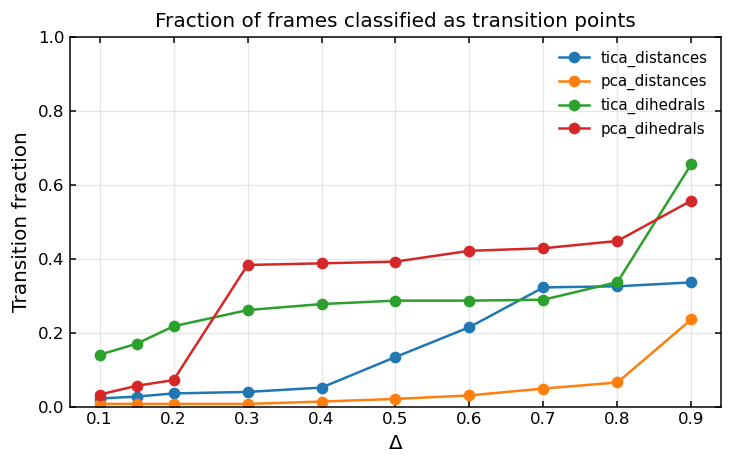

In [99]:
fig, ax = plt.subplots(figsize=(7, 4))

for name in trajectories_labels:
    df = summary_df[summary_df["name"] == name]

    ax.plot(
        df["delta"],
        df["transition_fraction"],
        marker="o",
        linewidth=1.5,
        label=name
    )

ax.set_xlabel(r"$\Delta$")
ax.set_ylabel("Transition fraction")
ax.set_title("Fraction of frames classified as transition points")
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
ax.legend(frameon=False)

plt.show()

The definition of transition points is very robust: the fraction of samples included in the transition region do not grow much over a large range of possible threshold choices.

In [100]:
summary_df["total"] = (
    summary_df["state0"] 
    + summary_df["state1"] 
    + summary_df["transition"]
)

summary_df["state0_fraction"] = summary_df["state0"] / summary_df["total"]
summary_df["state1_fraction"] = summary_df["state1"] / summary_df["total"]
summary_df["transition_fraction"] = summary_df["transition"] / summary_df["total"]

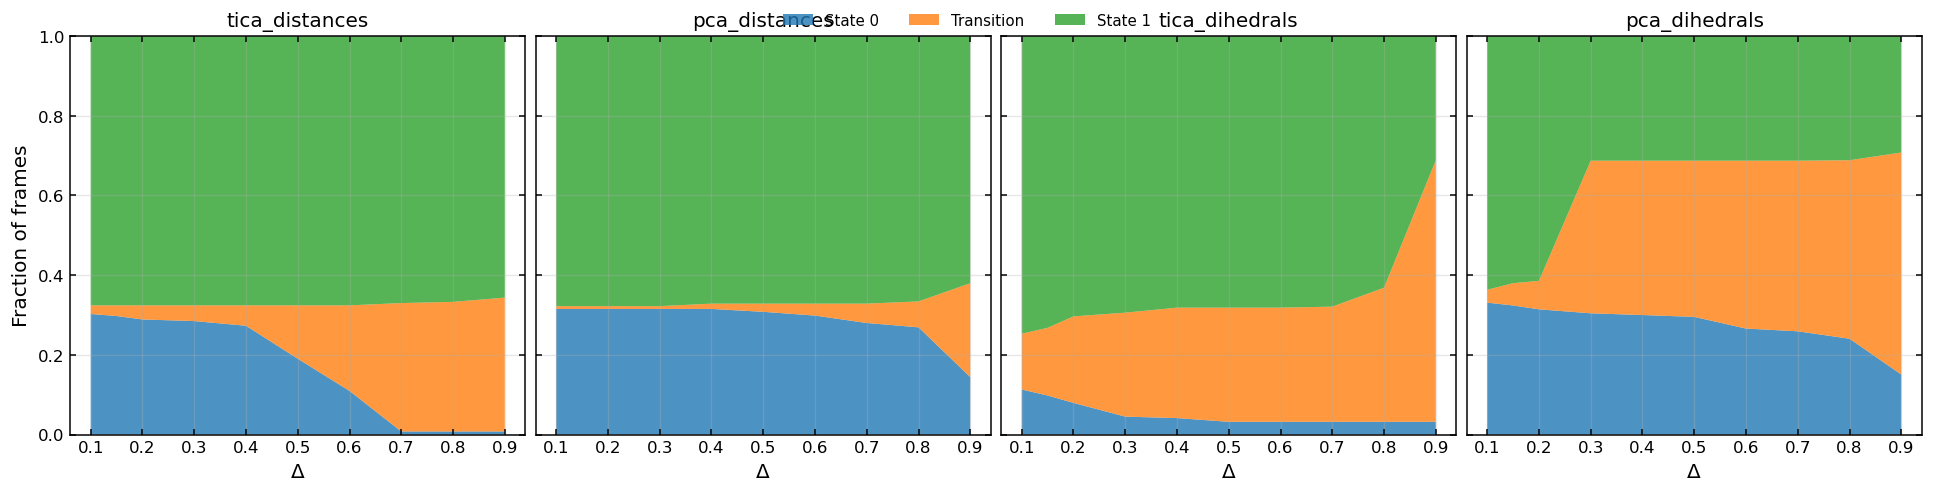

In [101]:
fig, axs = plt.subplots(
    nrows=1,
    ncols=len(trajectories_labels),
    figsize=(4 * len(trajectories_labels), 4),
    sharey=True,
    constrained_layout=True
)

if len(trajectories_labels) == 1:
    axs = [axs]

for ax, name in zip(axs, trajectories_labels):
    df = summary_df[summary_df["name"] == name].sort_values("delta")

    ax.stackplot(
        df["delta"],
        df["state0_fraction"],
        df["transition_fraction"],
        df["state1_fraction"],
        labels=["State 0", "Transition", "State 1"],
        alpha=0.8
    )

    ax.set_title(name)
    ax.set_xlabel(r"$\Delta$")
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)

axs[0].set_ylabel("Fraction of frames")

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    frameon=False
)

plt.show()

Caracterization of 

- ensemble with very high probability
- ensemble with $\simeq 0.5$ probability
- ensemble with very low probability

In [105]:
delta = 0.3

lower = 0.5 - delta / 2
upper = 0.5 + delta / 2

classification_dict = {}

for name in trajectories_labels:
    p = pcca_probabilities_timeseries_dict[name]

    state0_idx = np.where(p >= upper)[0]
    state1_idx = np.where(p <= lower)[0]
    transition_idx = np.where((p > lower) & (p < upper))[0]

    classification_dict[name] = {
        "state0": state0_idx,
        "state1": state1_idx,
        "transition": transition_idx
    }

    print(name)
    print(f"State 0: {len(state0_idx)}")
    print(f"State 1: {len(state1_idx)}")
    print(f"Transition: {len(transition_idx)}")
    print()

tica_distances
State 0: 434322
State 1: 1031509
Transition: 60210

pca_distances
State 0: 480825
State 1: 1034526
Transition: 10690

tica_dihedrals
State 0: 68414
State 1: 1059462
Transition: 398165

pca_dihedrals
State 0: 464131
State 1: 477496
Transition: 584414



In [106]:
transition_overlap = pd.DataFrame(
    index=trajectories_labels,
    columns=trajectories_labels,
    dtype=float
)

for name_a in trajectories_labels:
    A = set(classification_dict[name_a]["transition"])

    for name_b in trajectories_labels:
        B = set(classification_dict[name_b]["transition"])

        jaccard = len(A & B) / len(A | B)
        transition_overlap.loc[name_a, name_b] = jaccard

transition_overlap

,tica_distances,pca_distances,tica_dihedrals,pca_dihedrals
tica_distances,1.000000,0.144822,0.094460,0.019579
pca_distances,0.144822,1.000000,0.006318,0.005721
tica_dihedrals,0.094460,0.006318,1.000000,0.019995
pca_dihedrals,0.019579,0.005721,0.019995,1.000000
